In [1]:
from qiskit import QuantumCircuit

**This notebook shows different ways to display and control quantum circuits on Qiskit**

### Draw a quantum circuit

In [2]:
# Build a quantum circuit
circuit = QuantumCircuit(3, 3)
circuit.x(1)
circuit.h(range(3))
circuit.cx(0, 1)
circuit.measure(range(3), range(3));

In [3]:
print(circuit)

     ┌───┐          ┌─┐   
q_0: ┤ H ├───────■──┤M├───
     ├───┤┌───┐┌─┴─┐└╥┘┌─┐
q_1: ┤ X ├┤ H ├┤ X ├─╫─┤M├
     ├───┤└┬─┬┘└───┘ ║ └╥┘
q_2: ┤ H ├─┤M├───────╫──╫─
     └───┘ └╥┘       ║  ║ 
c: 3/═══════╩════════╩══╩═
            2        0  1 


In [4]:
circuit.draw()

┌───┐          ┌─┐   
q_0: ┤ H ├───────■──┤M├───
     ├───┤┌───┐┌─┴─┐└╥┘┌─┐
q_1: ┤ X ├┤ H ├┤ X ├─╫─┤M├
     ├───┤└┬─┬┘└───┘ ║ └╥┘
q_2: ┤ H ├─┤M├───────╫──╫─
     └───┘ └╥┘       ║  ║ 
c: 3/═══════╩════════╩══╩═
            2        0  1

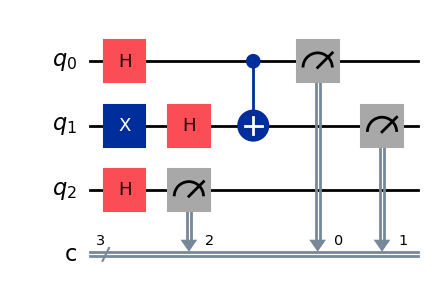

In [5]:
# Matplotlib drawing
circuit.draw(output="mpl")

#### Save output

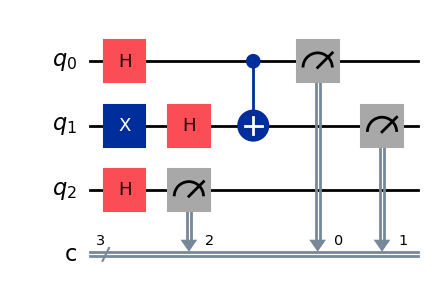

In [6]:
# Save as an image using the Matplotlib drawer
circuit.draw(output="mpl", filename="circuit-mpl.jpeg")

## Customize the output

In [8]:
from qiskit import QuantumRegister, ClassicalRegister
 
# Draw a new circuit with barriers and more registers
q_a = QuantumRegister(3, name="a")
q_b = QuantumRegister(5, name="b")
c_a = ClassicalRegister(3)
c_b = ClassicalRegister(5)
 
circuit = QuantumCircuit(q_a, q_b, c_a, c_b)
circuit.x(q_a[1])
circuit.x(q_b[1])
circuit.x(q_b[2])
circuit.x(q_b[4])
circuit.barrier()
circuit.h(q_a)
circuit.barrier(q_a)
circuit.h(q_b)
circuit.cswap(q_b[0], q_b[1], q_b[2])
# Controlled SWAP swaps q_b[1] and q_b[2] if q_b[0] == 1
circuit.cswap(q_b[2], q_b[3], q_b[4])
circuit.cswap(q_b[3], q_b[4], q_b[0])
circuit.barrier(q_b)
circuit.measure(q_a, c_a)
circuit.measure(q_b, c_b);

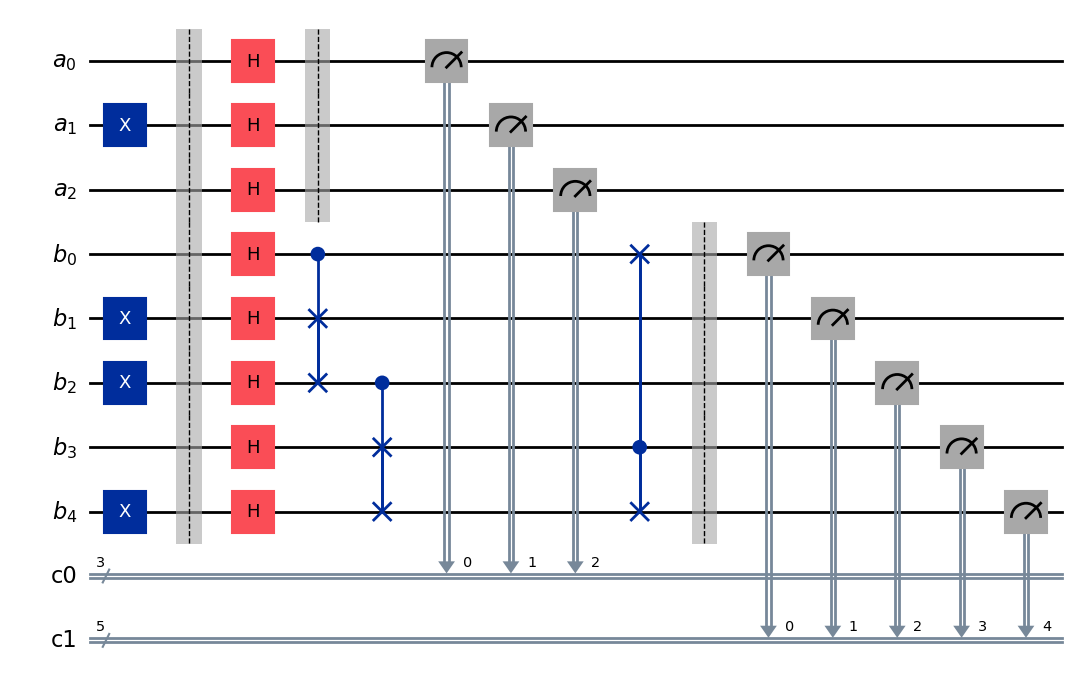

In [9]:
# Draw the circuit
circuit.draw(output="mpl")

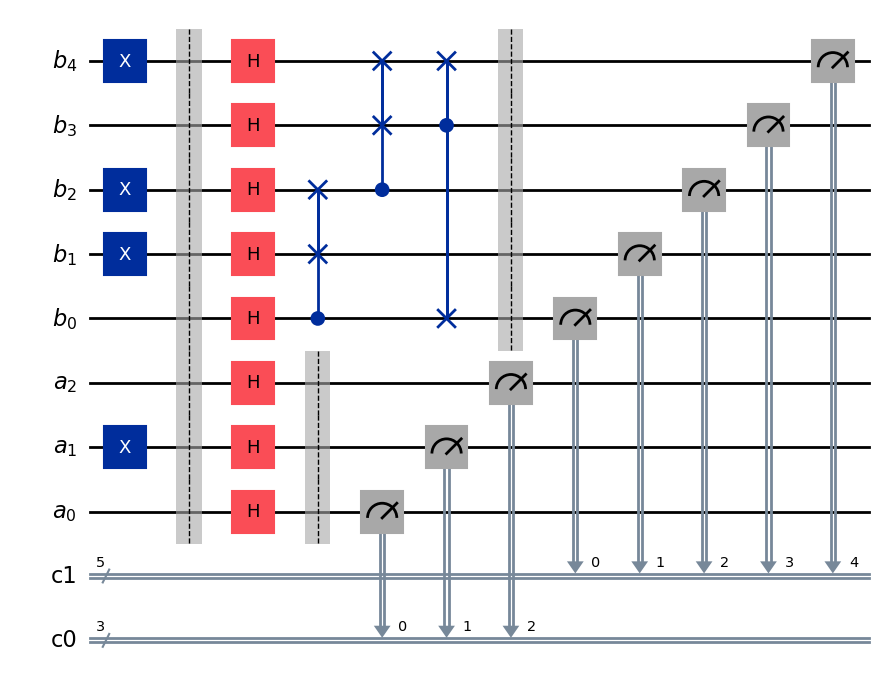

In [10]:
# Draw the circuit with reversed bit order
circuit.draw(output="mpl", reverse_bits=True)

## Renderer-specific customizations

In [13]:
circuit = QuantumCircuit(1)
for _ in range(10):
    circuit.h(0)
# limit line length to 40 characters
circuit.draw(output="text", fold=40)

┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
q: ┤ H ├┤ H ├┤ H ├┤ H ├┤ H ├┤ H ├┤ H ├»
   └───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«   ┌───┐┌───┐┌───┐
«q: ┤ H ├┤ H ├┤ H ├
«   └───┘└───┘└───┘

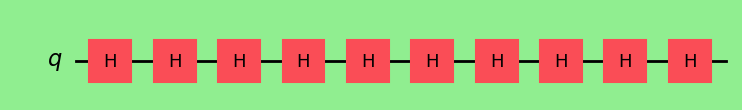

In [9]:
# Change the background color in mpl
 
style = {"backgroundcolor": "lightgreen"}
circuit.draw(output="mpl", style=style)

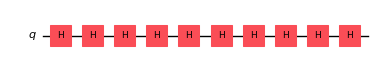

In [10]:
# Scale the mpl output to 1/2 the normal size
circuit.draw(output="mpl", scale=0.5)

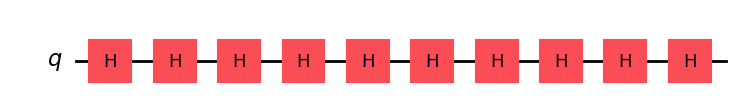

In [11]:
from qiskit.visualization import circuit_drawer
 
circuit_drawer(circuit, output="mpl", plot_barriers=False)